Author: @Bahae-Eddine Madir

# PINNs

In [1]:
import sys
import os
sys.path.insert(1, './Utilities/')

In [2]:
import torch
import numpy as np
from tqdm.notebook import tqdm

In [3]:
import matplotlib.pyplot as plt
from matplotlib import rc
rc('text', usetex=True)
rc('xtick', direction='in', top=True)
rc('ytick', direction='in', right=True)

In [4]:
case = 'pinns'
savedir = './outputs_' + case
os.makedirs(savedir, exist_ok=True)
save = True

In [5]:
# A (simple) feed forward N.N.
torch.manual_seed(1234)
class ff(torch.nn.Module):
    def __init__(self, n_neurones):
        super().__init__()
        self.l1 = torch.nn.Linear(2, n_neurones)
        self.act = torch.nn.Tanh()
        self.l2 = torch.nn.Linear(n_neurones, 1)
        self.params_dict = dict(self.named_parameters())
    def forward(self, *inputs):
        inputs = torch.cat(inputs, 1)
        outputs = self.act(self.l1(inputs))
        return self.l2(outputs)

device = torch.device("cpu")
net = ff(15).to(device)

In [6]:
model = net
# if strong BC
#model = lambda x, y: x* (x-1)* y* (y-1)* net(x, y)

In [7]:
# Manufactured Solution
u_ref = lambda x, y: torch.sin(torch.pi* x)* torch.sin(torch.pi* y) + (1/2)* torch.sin(3* torch.pi* x)* torch.sin(2* torch.pi* y)
f = lambda x, y: torch.pi**2* (2* torch.sin(torch.pi* x) + 13* torch.sin(3* torch.pi* x)* torch.cos(torch.pi* y))* torch.sin(torch.pi* y)

## Losses

In [8]:
from AutoDiff import AG_grad, args_requires_grad

In [9]:
@args_requires_grad
def res_mse(x, y):
    u = model(x, y)
    u_xx, u_yy = AG_grad(u, (x, y), order=2)
    res = u_xx + u_yy + f(x, y)
    return (res**2).mean()

In [10]:
def bdry_mse(x, y):
    u = model(x, y)
    return (u**2).mean()

In [11]:
def err_l2(ref, pred):
    return np.linalg.norm(ref - pred, 2) / np.linalg.norm(ref, 2)

## Data

In [12]:
n_bdry = 51* 4
n_res = 41**2
xl, xu = 0., 1.
yl, yu = 0., 1.
zeros = lambda *args: np.zeros_like(args[0])

In [13]:
from sampling import Sampler, Join_samplers

In [14]:
### Boundary
bc1_sampler = Sampler([xl, yl], [xl, yu], zeros) # at xl
bc2_sampler = Sampler([xu, yl], [xu, yu], zeros) # at xu
bc3_sampler = Sampler([xl, yl], [xu, yl], zeros) # at yl
bc4_sampler = Sampler([xl, yu], [xu, yu], zeros) # at yu
bcs_sampler = Join_samplers([bc1_sampler, bc2_sampler, bc3_sampler, bc4_sampler])

x_bdry, y_bdry, _ = bcs_sampler.sample(n_bdry, device=device)

In [15]:
res_sampler =  Sampler([xl, yl], [xu, yu], zeros)
x_res, y_res, _ = res_sampler.sample(n_res, device=device)

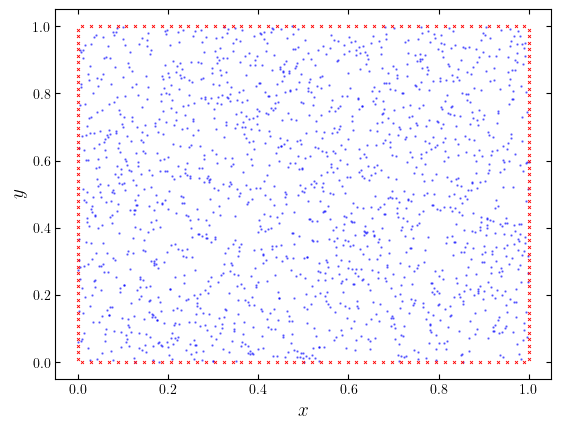

In [16]:
fig, ax = plt.subplots(1, 1)

plt.scatter(x_res.cpu(), y_res.cpu(), s=.5, c='b', alpha=.5, label='$(x_r, y_r)$')
plt.scatter(x_bdry, y_bdry, c='r', marker='x', s=.2, lw=3)
ax.set_ylabel("$y$", fontsize=14)
ax.set_xlabel("$x$", fontsize=14)
#plt.legend(loc='upper right')

if save:
    plt.savefig(savedir + '/res.pdf', bbox_inches ='tight')
plt.show()

## Optimization

In [17]:
w_b = 1000

In [18]:
losses = {'data':[], 'physics':[], 'total':[], 'l2':[]}

def closure():
    global l_data, l_phys
    net.zero_grad()
    l_data = bdry_mse(x_bdry, y_bdry)
    l_phys = res_mse(x_res, y_res)
    loss = l_phys + w_b* l_data
    loss.backward()
    return loss

In [19]:
optim = torch.optim.LBFGS(
    net.parameters(), 
    line_search_fn="strong_wolfe"
)
n_epochs = 101

In [20]:
nx = 100
x = torch.linspace(0, 1, nx).to(device)
x, y = torch.meshgrid(x, x, indexing="xy")
pred = model(
    x.reshape(-1, 1), 
    y.reshape(-1, 1)
).detach().reshape(nx, nx).cpu()
x = x.cpu()
y = y.cpu()
ref = u_ref(x, y)

In [21]:
%%time

for _ in tqdm(range(n_epochs)) :
    
    loss = optim.step(closure)
    
    # save
    losses['data'].append(l_data.item())
    losses['physics'].append(l_phys.item())
    losses['total'].append(loss.item())

    pred = model(x.reshape(-1, 1), y.reshape(-1, 1)).detach().reshape(nx, nx).cpu()
    losses['l2'].append(err_l2(ref, pred))

  0%|          | 0/101 [00:00<?, ?it/s]

CPU times: user 4min 19s, sys: 1.64 s, total: 4min 21s
Wall time: 22.5 s


In [22]:
nx = 100
x = torch.linspace(0, 1, nx)
x, y = torch.meshgrid(x, x, indexing='xy')

pred = model(
    x.reshape(-1, 1), 
    y.reshape(-1, 1)
).detach().reshape(nx, nx)

ref = u_ref(x, y)

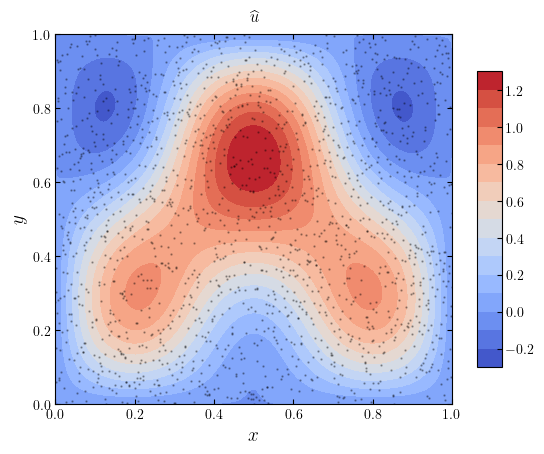

In [24]:
# Pred
fig, ax = plt.subplots(1, 1)

cb = ax.contourf(x, y, pred, cmap='coolwarm', levels=15)
fig.colorbar(cb, shrink=.8, aspect=12)

plt.scatter(x_res.detach(), y_res.detach(), s=.5, alpha=.3, c='k', label='$(x_r, y_r)$')

ax.set_title(r'$\widehat{u}$', pad=10, fontsize=12)
ax.set_ylabel("$y$", fontsize=14)
ax.set_xlabel("$x$", fontsize=14)

#plt.legend(loc='upper right')
if save:
    plt.savefig(savedir + '/pred.pdf', bbox_inches ='tight')
plt.show()

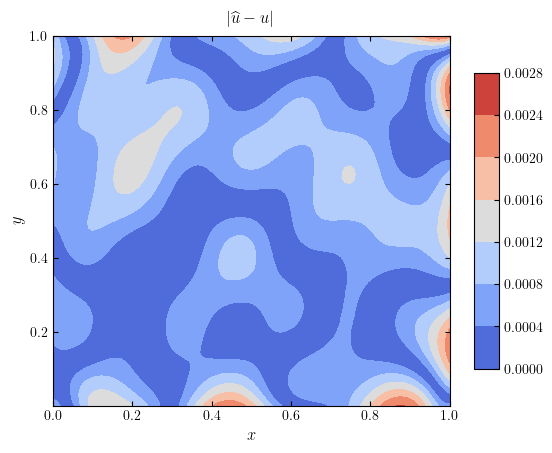

In [25]:
# Error
fig, ax = plt.subplots(1, 1)
ctf = ax.contourf(x, y, torch.abs(ref-pred), cmap='coolwarm', levels=6)
cb = fig.colorbar(ctf, shrink=.8, aspect=12)

ax.set_title(r'$|\widehat{u} - u|$', pad=10, fontsize=12)
ax.set_ylabel("$y$", fontsize=12)
ax.set_xlabel("$x$", fontsize=12)

ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1])

if save:
    plt.savefig(savedir + '/abs_error.pdf', bbox_inches ='tight')
plt.show()

In [26]:
print(f'Rel. L2 error : {err_l2(ref, pred) :.3e}')

Rel. L2 error : 1.031e-03


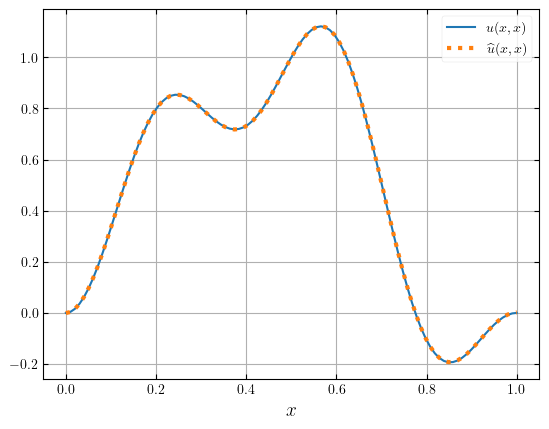

In [27]:
# Pred
fig, ax = plt.subplots(1, 1)

ax.grid(True)
ax.plot(np.diag(x), np.diag(ref), label='$u(x, x)$')
ax.plot(np.diag(x), np.diag(pred), ':', lw=3, label='$\widehat u(x, x)$')


#ax.set_title(r'(a).', pad=10, fontsize=12)
#ax.set_ylabel("$y$", fontsize=14)
ax.set_xlabel("$x$", fontsize=14)

plt.legend().get_frame().set_linewidth(0.25)

if save:
    plt.savefig(savedir + '/pred_diag.pdf', bbox_inches ='tight')
plt.show()

In [28]:
epochs = range(n_epochs)

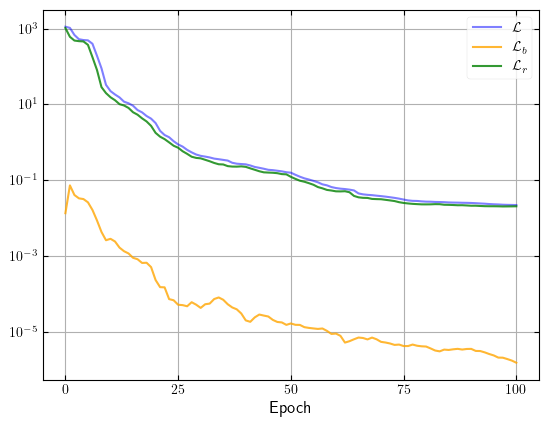

In [29]:
fig, axs = plt.subplots(1, 1)

axs.grid(True)
axs.set_yscale('log')
axs.set_xlabel('Epoch', fontsize=12)

axs.plot(epochs, losses['total'], "-", color='blue', lw=1.5, alpha=.5, label='$\mathcal{L}$')
axs.plot(epochs, losses['data'], "-", color='orange', lw=1.5, alpha=.8, label='$\mathcal{L}_b$')
axs.plot(epochs, losses['physics'], "-", color='green', lw=1.5, alpha=.8, label='$\mathcal{L}_r$')


axs.set_xticks(epochs[::25])
axs.legend().get_frame().set_linewidth(0.25)

if save:
    plt.savefig(savedir + '/losses.pdf', bbox_inches ='tight')
plt.show()

In [30]:
marker_kw = dict(
    markevery=20, markersize=5, markerfacecolor="none"
)

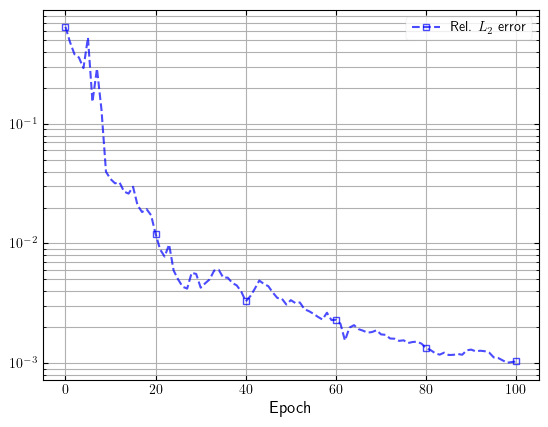

In [31]:
fig, axs = plt.subplots(1, 1)

axs.grid(True, which='both')
axs.set_yscale('log')
axs.set_xlabel('Epoch', fontsize=12)

axs.plot(epochs, losses['l2'], "--s", color='blue', alpha=.7, label='Rel. $L_2$ error', **marker_kw)
#axs.set_xticks(epochs)
axs.legend().get_frame().set_linewidth(0.25)

if save:
    plt.savefig(savedir + '/l2_error.pdf', bbox_inches ='tight')
plt.show()

In [33]:
np.savetxt(
    savedir+'/l2_error1',
    losses['l2']
)